In [332]:
#import kaggle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

dt = pd.read_csv('insurance.csv', sep=',')
print(dt.head())
print(dt.columns)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [333]:
dataFrame = pd.DataFrame

# Strip whitespace and make all column names uppercase
dt.columns = dt.columns.str.strip().str.upper()
print(dt.columns)

dt.dropna
dataTrain= dt.drop(columns=['REGION'])
dataTrain['SMOKER'] = dataTrain['SMOKER'].map({'yes': 1, 'no': 0})
dataTrain['SEX'] = dataTrain['SEX'].map({'female': 1, 'male': 0})

display(dataTrain.head())

Index(['AGE', 'SEX', 'BMI', 'CHILDREN', 'SMOKER', 'REGION', 'CHARGES'], dtype='object')


,AGE,SEX,BMI,CHILDREN,SMOKER,CHARGES
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520


In [334]:
# Separate label before dropping the column
labels = dataTrain['CHARGES'].values

# Create a features DataFrame by dropping 'CHARGES', without modifying the original
features = dataTrain.drop('CHARGES', axis=1)
feature_names = features.columns.tolist()


In [335]:

# split the dataset
from sklearn.model_selection import train_test_split
featuresTrain, featuresTest, labelsTrain, labelsTest = train_test_split(
    features, labels, test_size=0.05, random_state=42
)

print(featuresTrain.shape)
input_shape = features.shape[1]


(1271, 5)


In [336]:
def compute_cost(X, y, theta):
    m = len(y)
    y = y.reshape(-1, 1)
    predictions = X.dot(theta)
    sq_errors = (predictions - y) ** 2
    cost = (1 / (2 * m)) * np.sum(sq_errors)
    return cost

def compute_gradient(X, y, theta):
    m = len(y)
    y = y.reshape(-1, 1)  # make y shape (m,1) to match predictions
    predictions = X.dot(theta)
    gradient = (1 / m) * X.T.dot(predictions - y)
    return gradient

def gradient_descent(X, y, theta, learningRate, num_iters):
    costHistory = []  # store cost at each iteration 

    for i in range(num_iters):
        #vectorized gradient
        gradient = compute_gradient(X, y, theta)
        theta = theta - learningRate * gradient
        
        # record  cost for convergence tracking
        costHistory.append(compute_cost(X, y, theta))

    return theta, costHistory



In [337]:
'''
featuresNumpy = featuresTrain.to_numpy().astype(np.float64) 

# Get the number of features from the  data
num_features = featuresTrain.shape[1] 
# Initialize theta as a vector of zeros (num_features, 1)
theta = np.zeros((num_features, 1)) # should be (6, 1) or (6,)

print(theta.shape)
optimizedWeights, optimizedCosts = gradient_descent(featuresNumpy, labelsTrain, theta, 0.01, 10)
print(optimizedWeights.shape)
'''

'\nfeaturesNumpy = featuresTrain.to_numpy().astype(np.float64) \n\n# Get the number of features from the  data\nnum_features = featuresTrain.shape[1] \n# Initialize theta as a vector of zeros (num_features, 1)\ntheta = np.zeros((num_features, 1)) # should be (6, 1) or (6,)\n\nprint(theta.shape)\noptimizedWeights, optimizedCosts = gradient_descent(featuresNumpy, labelsTrain, theta, 0.01, 10)\nprint(optimizedWeights.shape)\n'

In [338]:
def predict(X_new, theta):
    predictions = X_new.dot(theta)
    return predictions.ravel()  # flatten to 1D

def calculate_mae(y_true, y_pred):
    #Calculates the Mean Absolute Error
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    errors = y_true - y_pred
    mae = np.mean(np.abs(errors))
    return mae

In [ ]:
featuresNumpy = featuresTrain.to_numpy().astype(np.float64)
labelsNumpy = labelsTrain.reshape(-1, 1)   # make labels column vector

theta = np.zeros((num_features, 1))
optimizedWeights, optimizedCosts = gradient_descent(featuresNumpy, labelsNumpy, theta, 0.01, 10)

# predict
predictions = predict(featuresTest.to_numpy().astype(np.float64), optimizedWeights)
print("labelsTest shape:", labelsTest.shape)
print("predictions shape:", predictions.shape)

print(predictions)
print("++++++++++++++++++++++++++++++++++++")
print(labelsTest)
#print("Evaluations:"+str(calculate_mae(labelsTest, predictions)))



labelsTest shape: (67,)
predictions shape: (67,)
[-1.43469767e+18 -1.31075070e+18 -1.89085047e+18 -1.46704566e+18
 -9.58402097e+17 -1.47956606e+18 -8.02559650e+17 -2.07326487e+18
 -9.19034775e+17 -1.58360643e+18 -1.08370668e+18 -1.43396759e+18
 -1.14620520e+18 -1.74257337e+18 -2.03309664e+18 -1.70799979e+18
 -1.81533004e+18 -1.66936227e+18 -1.50437070e+18 -1.41685722e+18
 -9.63619136e+17 -1.51244881e+18 -9.33082828e+17 -1.15705480e+18
 -1.59698514e+18 -1.76115091e+18 -1.93671705e+18 -1.11566706e+18
 -1.50347575e+18 -9.06199212e+17 -1.39143070e+18 -1.81468271e+18
 -1.05262896e+18 -1.01005070e+18 -1.08503043e+18 -1.67592832e+18
 -9.12725174e+17 -1.46734253e+18 -1.57488565e+18 -1.39709935e+18
 -9.06411325e+17 -1.01713787e+18 -1.85862770e+18 -1.75398945e+18
 -1.33898544e+18 -1.78841053e+18 -1.03323057e+18 -9.69346754e+17
 -1.56903771e+18 -1.33763178e+18 -2.02433426e+18 -8.94012028e+17
 -1.59070652e+18 -8.39604125e+17 -1.83505768e+18 -1.66231914e+18
 -1.09942734e+18 -1.27197765e+18 -1.85840

In [340]:
scaler = StandardScaler()
# Fit and transform training features
X_train_scaled = scaler.fit_transform(featuresTrain.to_numpy().astype(np.float64))
# Transform test features
X_test_scaled = scaler.transform(featuresTest.to_numpy().astype(np.float64))

# Add the intercept term (column of ones) to the scaled data
# This is necessary because the GD functions assume theta includes the bias term.
X_train_final = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test_final = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

# 3b. Setup Hyperparameters and Initial Theta
num_features_with_intercept = X_train_final.shape[1]
theta_initial = np.zeros((num_features_with_intercept, 1))
learningRate = 0.01
num_iters = 5000  # Increased iterations for reliable convergence

# Reshape labels for matrix operations
labelsNumpyTrain = labelsTrain.reshape(-1, 1)

# 3c. Train Model
optimizedWeights, optimizedCosts = gradient_descent(
    X_train_final, labelsNumpyTrain, theta_initial, learningRate, num_iters
)

# 3d. Predict on Test Set
test_predictions = predict(X_test_final, optimizedWeights)

# 3e. Calculate Fitted Values and Residuals for Plot 1 (using Training Data)
fitted_values_train = predict(X_train_final, optimizedWeights)
residuals_train = labelsTrain - fitted_values_train

# 3f. Final Evaluation
mae_score = calculate_mae(labelsTest, test_predictions)
print(f"\nModel Evaluation (MAE on Test Set): ${mae_score:.2f}")


Model Evaluation (MAE on Test Set): $3906.26


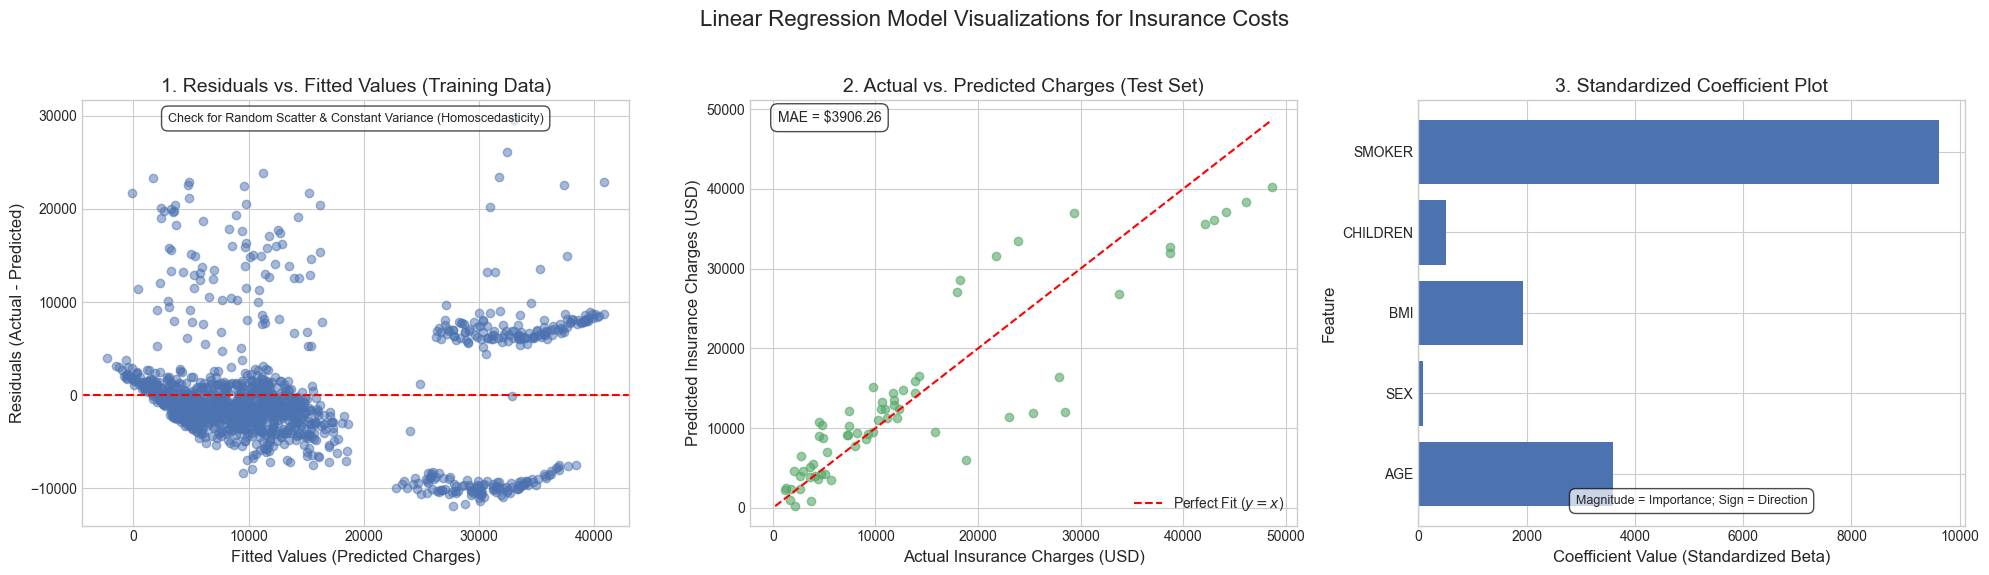

In [341]:

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Linear Regression Model Visualizations for Insurance Costs', fontsize=16)

# PLOT 1: RESID VS FITTED

ax1 = axes[0]
ax1.scatter(fitted_values_train, residuals_train, alpha=0.5, color='#4c72b0')
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_title('1. Residuals vs. Fitted Values (Training Data)', fontsize=14)
ax1.set_xlabel('Fitted Values (Predicted Charges)', fontsize=12)
ax1.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
# Text notes for report interpretation
ax1.text(0.5, 0.95, 'Check for Random Scatter & Constant Variance (Homoscedasticity)', 
         transform=ax1.transAxes, horizontalalignment='center', fontsize=9, 
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7))


#ACTUAL VS PREDCITED

ax2 = axes[1]
ax2.scatter(labelsTest, test_predictions, alpha=0.6, color='#55a868')
# Plot the ideal line (y=x)
min_val = min(labelsTest.min(), test_predictions.min())
max_val = max(labelsTest.max(), test_predictions.max())
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit ($y=x$)')

ax2.set_title('2. Actual vs. Predicted Charges (Test Set)', fontsize=14)
ax2.set_xlabel('Actual Insurance Charges (USD)', fontsize=12)
ax2.set_ylabel('Predicted Insurance Charges (USD)', fontsize=12)
ax2.legend()
# Add MAE score for context
ax2.text(0.05, 0.95, f'MAE = ${mae_score:.2f}', transform=ax2.transAxes, 
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7), fontsize=10)


#Coeffiecent bar plot

standardized_coefficients = optimizedWeights[1:].flatten()
feature_labels = feature_names

ax3 = axes[2]

colors = ['#4c72b0' if c > 0 else '#ccb974' for c in standardized_coefficients] 
ax3.barh(feature_labels, standardized_coefficients, color=colors)
ax3.axvline(x=0, color='gray', linestyle='--')
ax3.set_title('3. Standardized Coefficient Plot', fontsize=14)
ax3.set_xlabel('Coefficient Value (Standardized Beta)', fontsize=12)
ax3.set_ylabel('Feature', fontsize=12)
ax3.tick_params(axis='y', labelsize=10)

ax3.text(0.5, 0.05, 'Magnitude = Importance; Sign = Direction', transform=ax3.transAxes, horizontalalignment='center', fontsize=9, 
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7))


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()